Index(['fid', 'field_1', 'road', 'id', 'model_type', 'condition', 'name',
       'lat', 'lon', 'length', 'avg_truck_AADT', 'WMO_WIND_I', 'distance',
       'elevation'],
      dtype='object')


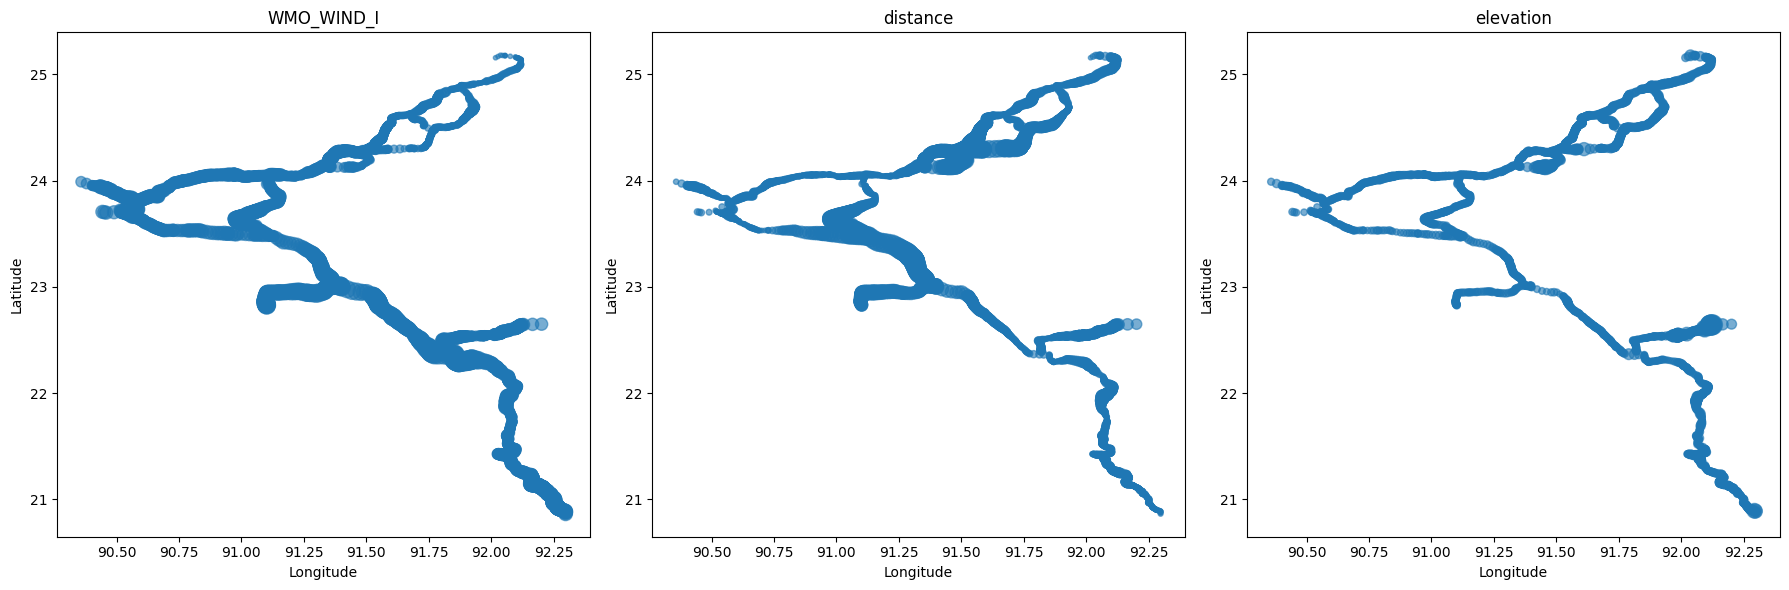

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data inlezen
df = pd.read_csv("../data/data_final_with_aadt_and_vulnerability.csv")

# Controleer kolomnamen
print(df.columns)

# 2. Zorg dat lon/lat bestaan (pas namen aan indien nodig)
lon = df['lon']
lat = df['lat']

# 3. Variabelen
variables = ['WMO_WIND_I', 'distance', 'elevation']

# 4. Subplots maken
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, variables):
    values = df[var]

    # Schaal puntgrootte (optioneel aanpassen)
    sizes = (values - values.min()) / (values.max() - values.min()) * 200 + 10

    sc = ax.scatter(lon, lat, s=sizes, alpha=0.6)

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

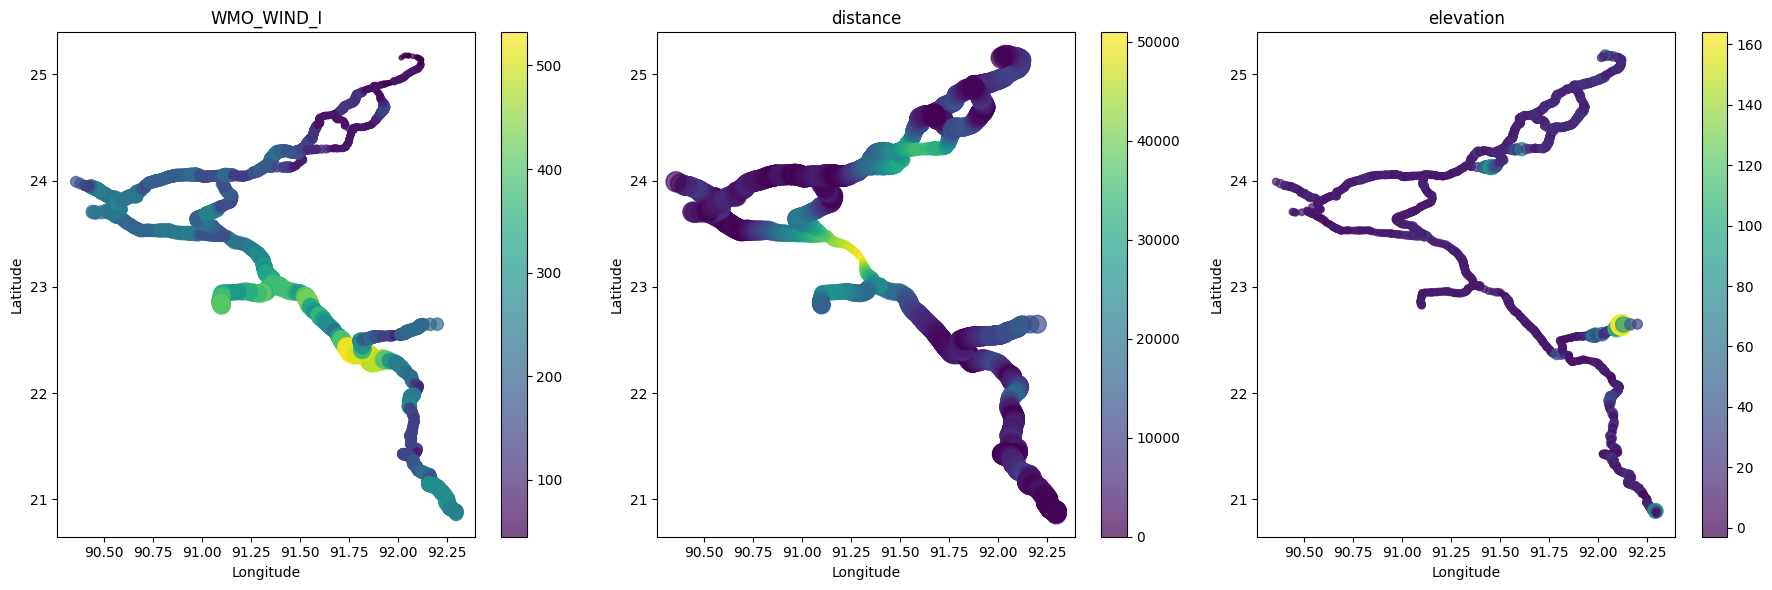

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, variables):
    values = df[var]

    # Normalisatie
    norm = (values - values.min()) / (values.max() - values.min())

    if var == 'distance':
        # Omgekeerd: kleine distance = grote stip
        sizes = (1 - norm) * 200 + 10
    else:
        # Normaal: grote waarde = grote stip
        sizes = norm * 200 + 10

    sc = ax.scatter(lon, lat, s=sizes, c=values, cmap='viridis', alpha=0.7)

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()


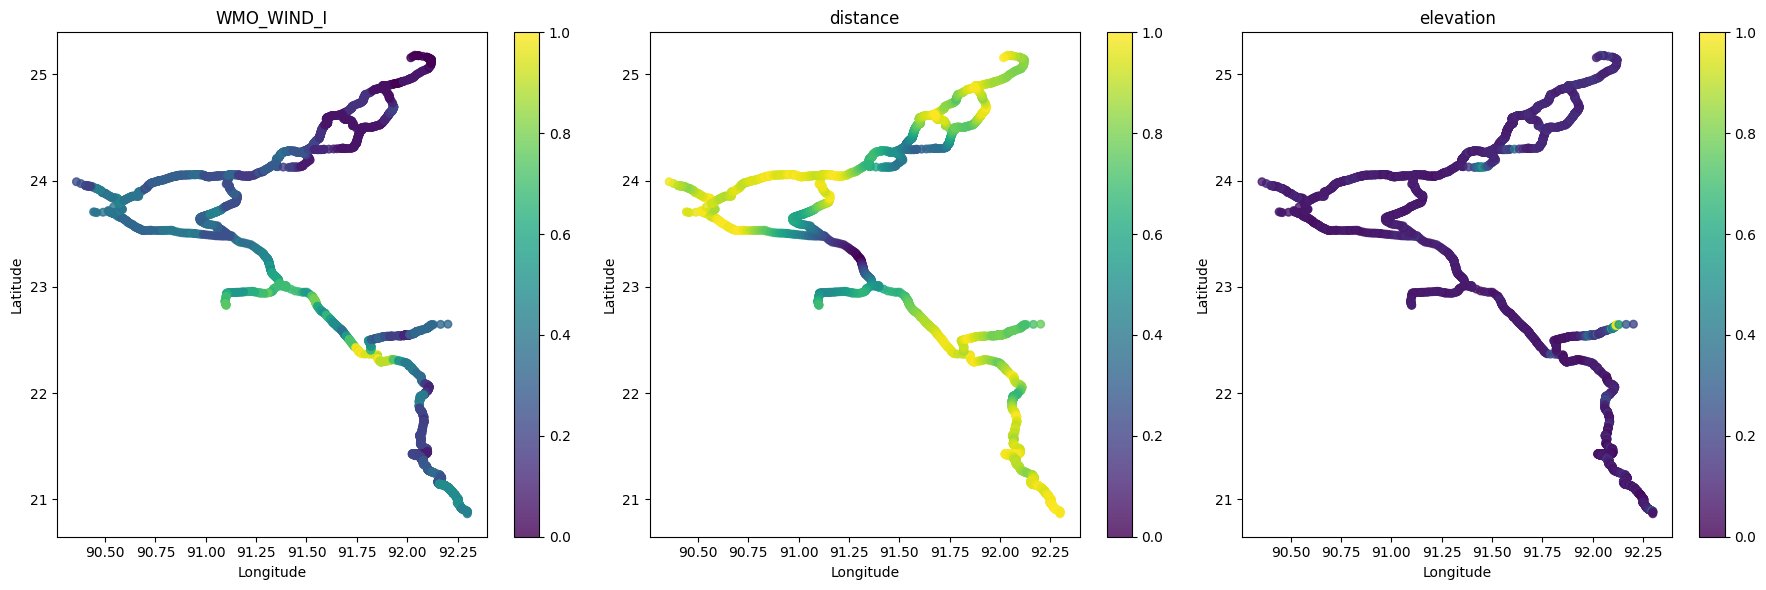

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, variables):
    values = df[var]

    # Normalisatie
    norm = (values - values.min()) / (values.max() - values.min())

    if var == 'distance':
        # Omgekeerde kleur: kleine distance = "hogere" kleurwaarde
        colors = 1 - norm
    else:
        colors = norm

    sc = ax.scatter(lon, lat, c=colors, cmap='viridis', s=30, alpha=0.8)

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()